<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype              
---  ------     --------------    -----              
 0   headline   1048571 non-null  object             
 1   url        1048575 non-null  object             
 2   publisher  1048575 non-null  object             
 3   date       1048575 non-null  datetime64[ns, UTC]
 4   stock      1048575 non-null  object             
dtypes: datetime64[ns, UTC](1), object(4)
memory usage: 40.0+ MB


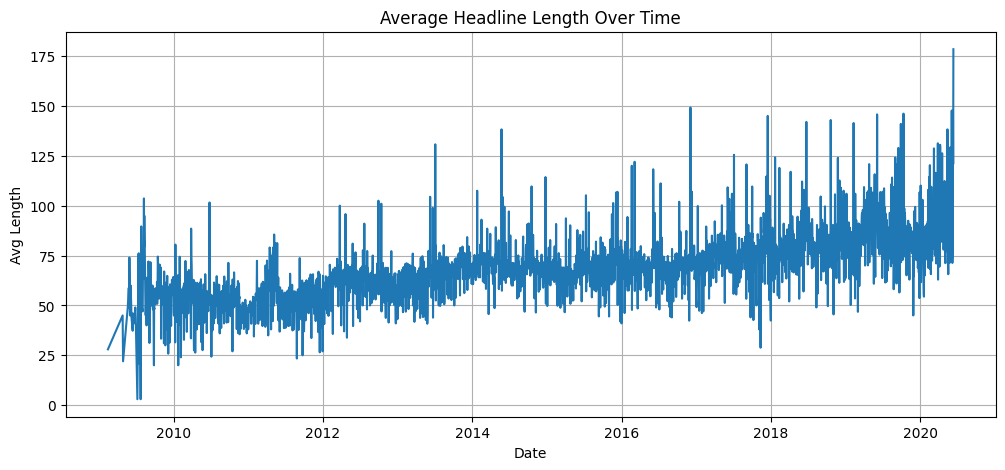

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Load Data
df = pd.read_excel('C:\\Users\\ayedr\\week-1\\notebooks\\raw_analyst_ratings.xlsx')

# Drop the redundant index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert date to datetime with timezone handled
df['date'] = pd.to_datetime(df['date'], utc=True)

# Preview more info
df.info()
df.describe(include='all')

# Group headlines by date or stock for EDA
df['date_only'] = df['date'].dt.date

# Drop missing and non-string headlines
df = df.dropna(subset=['headline'])
df = df[df['headline'].apply(lambda x: isinstance(x, str))]

# Compute headline lengths
df['headline_length'] = df['headline'].apply(len)

# Plot average headline length over time
df.groupby('date_only')['headline_length'].mean().plot(kind='line', figsize=(12, 5))
plt.title("Average Headline Length Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Length")
plt.grid(True)
plt.show()
#I plotted the average headline length per day.
# So that it helps spot editorial trends — maybe shorter headlines during breaking news, or longer during analysis pieces.


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import corpora, models
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if not already
nltk.download('stopwords')

# Assume news_df already exists
# If not already assigned, do this (if variable is something else):
# news_df = your_loaded_dataframe_variable_name

# Clean and tokenize headlines
stop_words = stopwords.words('english')
news_df['tokens'] = news_df['headline'].astype(str).str.lower().str.split()
news_df['tokens'] = news_df['tokens'].apply(
    lambda x: [w for w in x if w not in stop_words and len(w) > 2]
)

# Topic modeling with Gensim LDA
dictionary = corpora.Dictionary(news_df['tokens'])
corpus = [dictionary.doc2bow(text) for text in news_df['tokens']]
lda = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Print topics
topics = lda.print_topics()
for topic in topics:
    print(topic)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayedr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'news_df' is not defined